In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score

In [35]:
df = pd.read_csv("saved_files/df_boyas_tiffs.csv")
df = df.drop(columns=["Latitude", "Longitude", "Band_8", "Band_9", "Band_10", "Band_11", "Band_12", "Band_13"])
df = df.rename(columns={"Band_1" : "UltraBlue", "Band_2" : "Blue", "Band_3" : "Green", "Band_4" : "Red", "Band_5" : "NIR1", "Band_6" : "NIR2", "Band_7" : "NIR3"})
df['Date'] = pd.to_datetime(df['Date'])
dates = df["Date"].copy()
df = df.drop(columns=["Date","Buoy"]) # No quitamos "Date" para tener la fecha y poner saber si los malos resultados se dan cuando hay más turbidez
df.loc[:, ['UltraBlue', 'Blue', 'Green', 'Red', 'NIR1', 'NIR2', 'NIR3']] += 1

In [36]:
df.loc[:, df.columns != "Chl"] = df.loc[:, df.columns != "Chl"] / 256

In [37]:
df.head(3)

,UltraBlue,Blue,Green,Red,NIR1,NIR2,NIR3,Chl
0,0.105469,0.097656,0.105469,0.085938,0.093750,0.089844,0.089844,1.122533
1,0.042969,0.050781,0.054688,0.031250,0.027344,0.019531,0.019531,0.991597
2,0.066406,0.082031,0.085938,0.066406,0.058594,0.054688,0.054688,1.195585


In [38]:
df.describe()

,UltraBlue,Blue,Green,Red,NIR1,NIR2,NIR3,Chl
count,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000
mean,0.046547,0.053097,0.058977,0.041364,0.040827,0.036900,0.037312,1.989064
std,0.073950,0.070367,0.066583,0.064565,0.069359,0.066738,0.065428,2.773688
min,0.003906,0.003906,0.003906,0.003906,0.003906,0.003906,0.003906,0.068182
25%,0.019531,0.023438,0.030273,0.011719,0.011719,0.007812,0.007812,0.511931
50%,0.035156,0.042969,0.048828,0.027344,0.027344,0.019531,0.023438,0.894220
75%,0.062500,0.066406,0.078125,0.058594,0.058594,0.054688,0.054688,2.178460
max,1.000000,1.000000,0.929688,0.894531,0.953125,0.914062,0.902344,21.019255


### 1. De "Análisis multisensor de la variabilidad espacio temporal de diversos parámetros biofísicos en el Mar Menor"

La fórmula que se propone en este artículo es $y = 0.6386 e^{4.7513x}$, donde $y$ es la clorofila y $x$ es la relación de $(Green - Blue)/(Green + Blue)$

In [39]:
def norm_dif(band1, band2):
    index = (band1 - band2)/(band1 + band2)
    return index

def add_index_green_blue(data):
    df["norm_dif_green_blue"] = norm_dif(data["Green"], data["Blue"])
    df[f"index_green_blue"] = 0.6386*np.exp(4.7513*(norm_dif(data["Green"], data["Blue"])))
add_index_green_blue(df)

In [40]:

r2 = r2_score(df["Chl"], df["index_green_blue"])
print('Train R squared: %.3f' % r2)

Train R squared: -0.031


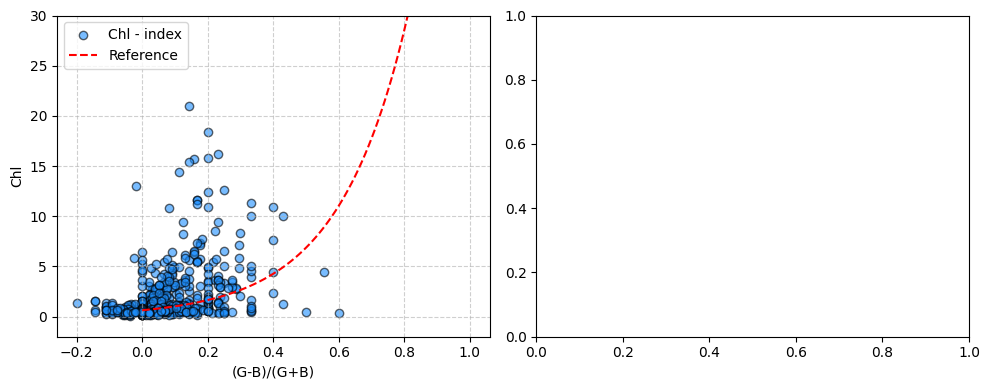

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Train plot
axes[0].scatter(df["norm_dif_green_blue"], df["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label="Chl - index")
axes[0].plot(np.linspace(0,1, 101), 0.6386*np.exp(4.7513*(np.linspace(0,1, 101))), color="red", linestyle="--", label="Reference")
axes[0].set_xlabel("(G-B)/(G+B)")
axes[0].set_ylabel("Chl")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_ylim(-2,30)

# Test plot
# axes[1].scatter(y_test, test_prediction, color="orange", alpha=0.6, edgecolor="k", label="Test prediction")
# axes[1].plot(y_test, y_test, color="red", linestyle="--", label="Reference")
# axes[1].set_xlabel("Observed Chl")
# axes[1].set_ylabel("Predicted Chl")
# axes[1].legend()
# axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()